# Digital Marketing — Conversion Classification

In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1) Exploratory Data Analysis

In [69]:
path1 = r"D:\final project ML\digital_marketing_campaign_dataset.csv"
df = pd.read_csv(path1)
print("Shape:", df.shape)
df.head(10)

Shape: (8000, 20)


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1
5,8005,25,Female,42925,Social Media,Awareness,9579.388247,0.153795,0.161316,6,2.125850,7.752831,95,5,8,0,3316,IsConfid,ToolConfid,1
6,8006,38,Female,25615,Referral,Awareness,7302.899852,0.040975,0.060977,42,1.753995,10.698672,54,14,3,6,930,IsConfid,ToolConfid,1
7,8007,56,Female,57083,Social Media,Conversion,5324.283667,0.052878,0.188946,48,2.626015,2.987817,96,9,3,0,2983,IsConfid,ToolConfid,1
8,8008,36,Female,140788,Email,Retention,9421.250951,0.023536,0.112585,13,5.472843,14.287421,73,4,8,5,460,IsConfid,ToolConfid,1
9,8009,40,Male,130764,Social Media,Awareness,6229.193333,0.066641,0.169786,22,1.135665,4.613312,14,8,4,8,3789,IsConfid,ToolConfid,1


In [70]:
df['AdvertisingPlatform'].value_counts()

AdvertisingPlatform
IsConfid    8000
Name: count, dtype: int64

In [71]:
print("Shape:", df.shape)
df.info()

Shape: (8000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases   

In [72]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values per column:
CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64

Number of duplicate rows: 0


In [73]:
df.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


In [74]:
df['Gender'].value_counts()

Gender
Female    4839
Male      3161
Name: count, dtype: int64

In [75]:
df['CampaignChannel'].value_counts()

CampaignChannel
Referral        1719
PPC             1655
Email           1557
SEO             1550
Social Media    1519
Name: count, dtype: int64

In [76]:
df['CampaignType'].value_counts()

CampaignType
Conversion       2077
Awareness        1988
Consideration    1988
Retention        1947
Name: count, dtype: int64

In [77]:
conversion_counts = df['Conversion'].value_counts()
conversion_percentages = df['Conversion'].value_counts(normalize=True) * 100

print(conversion_counts)
print(conversion_percentages)

Conversion
1    7012
0     988
Name: count, dtype: int64
Conversion
1    87.65
0    12.35
Name: proportion, dtype: float64


In [78]:
df.groupby('Conversion')['ConversionRate'].describe()

,count,mean,std,min,25%,50%,75%,max
Conversion,,,,,,,,
0,988.0,0.090766,0.058373,0.010018,0.037929,0.081513,0.141856,0.199710
1,7012.0,0.106308,0.054097,0.010059,0.060157,0.106523,0.153014,0.199995


In [79]:
for col in ['Gender', 'CampaignChannel', 'CampaignType']:
    print(f"--- {col} ---")
    print(df.groupby(col)['Conversion'].mean().sort_values(ascending=False))
    print()

--- Gender ---
Gender
Male      0.876938
Female    0.876214
Name: Conversion, dtype: float64

--- CampaignChannel ---
CampaignChannel
Referral        0.883072
PPC             0.882779
SEO             0.876774
Email           0.870263
Social Media    0.868334
Name: Conversion, dtype: float64

--- CampaignType ---
CampaignType
Conversion       0.933558
Retention        0.858243
Awareness        0.855634
Consideration    0.855634
Name: Conversion, dtype: float64



Conversion
1    7012
0     988
Name: count, dtype: int64
Conversion
1    87.65
0    12.35
Name: proportion, dtype: float64


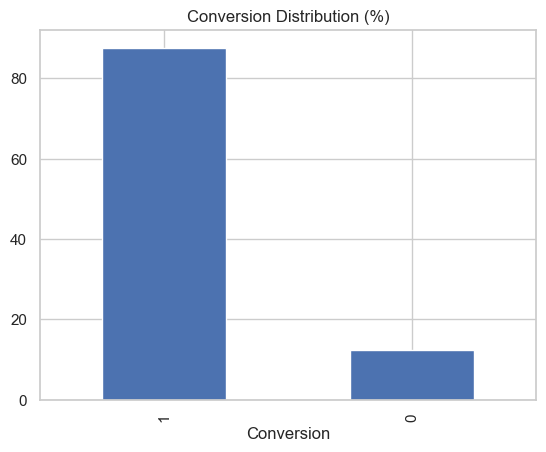

In [80]:
conversion_pct = df["Conversion"].value_counts(normalize=True).mul(100).round(2)
print(df["Conversion"].value_counts())
print(conversion_pct)

conversion_pct.plot(kind="bar", title="Conversion Distribution (%)")
plt.show()

In [81]:
numeric_cols = [
    "Age", "Income", "AdSpend", "ClickThroughRate", "ConversionRate",
    "WebsiteVisits", "PagesPerVisit", "TimeOnSite", "SocialShares",
    "EmailOpens", "EmailClicks", "PreviousPurchases", "LoyaltyPoints",
]

for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: {n_outliers} outliers (bounds: {lower:.2f} to {upper:.2f})")

Age: 0 outliers (bounds: -6.50 to 93.50)
Income: 0 outliers (bounds: -45862.38 to 214422.62)
AdSpend: 0 outliers (bounds: -4803.93 to 14735.14)
ClickThroughRate: 0 outliers (bounds: -0.14 to 0.45)
ConversionRate: 0 outliers (bounds: -0.09 to 0.30)
WebsiteVisits: 0 outliers (bounds: -23.00 to 73.00)
PagesPerVisit: 0 outliers (bounds: -3.50 to 14.64)
TimeOnSite: 0 outliers (bounds: -7.05 to 22.60)
SocialShares: 0 outliers (bounds: -50.00 to 150.00)
EmailOpens: 0 outliers (bounds: -8.50 to 27.50)
EmailClicks: 0 outliers (bounds: -5.50 to 14.50)
PreviousPurchases: 0 outliers (bounds: -5.50 to 14.50)
LoyaltyPoints: 0 outliers (bounds: -2416.50 to 7373.50)


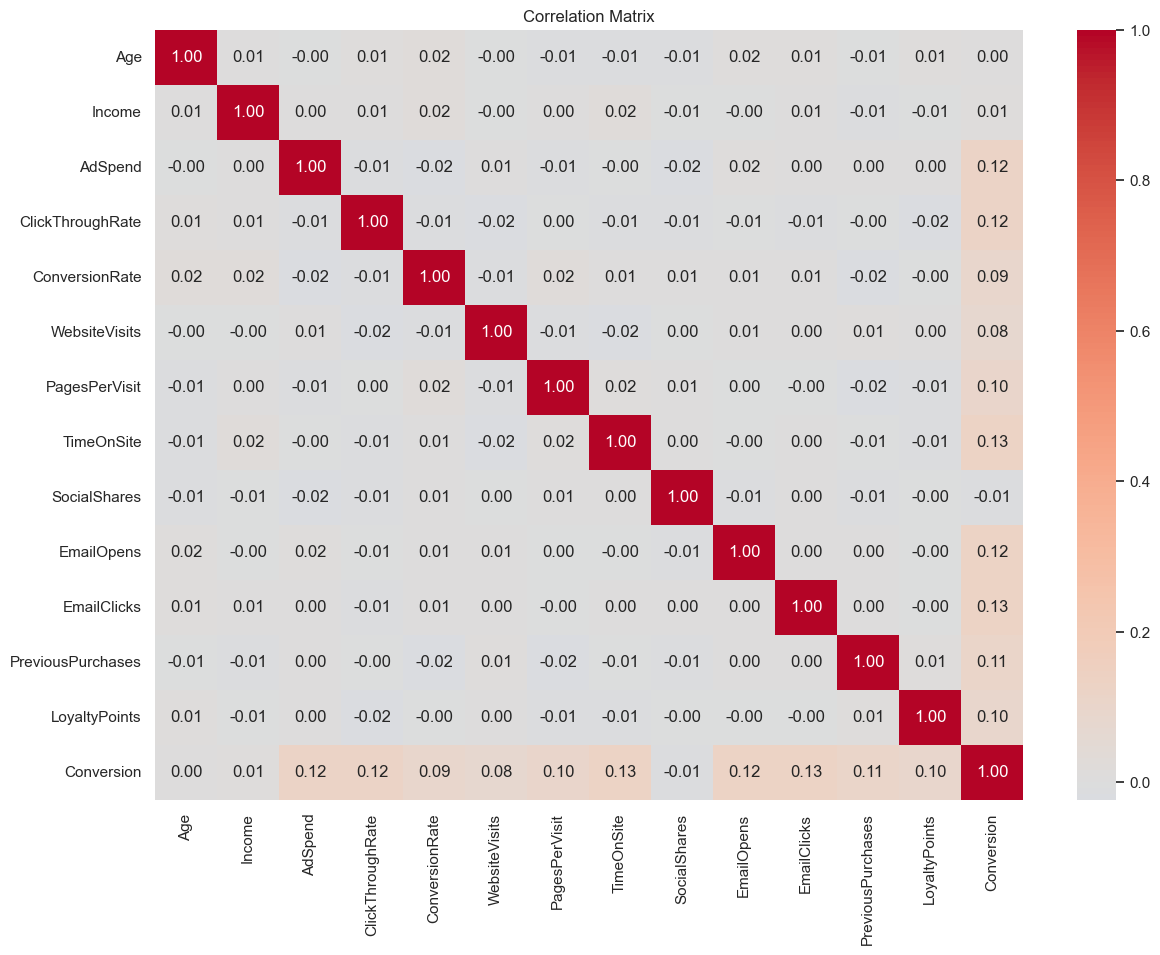

In [82]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols + ["Conversion"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [83]:
print("EmailClicks > EmailOpens:", (df["EmailClicks"] > df["EmailOpens"]).sum())

EmailClicks > EmailOpens: 1777


## 2) Preprocessing

In [84]:
ID_COLUMNS = ["CustomerID"]
ZERO_VARIANCE_COLUMNS = ["AdvertisingPlatform", "AdvertisingTool"]

X = df.drop(columns=["Conversion"] + ID_COLUMNS + ZERO_VARIANCE_COLUMNS)
y = df["Conversion"]

In [85]:
X["Gender"] = X["Gender"].map({"Male": 1, "Female": 0})
X = pd.get_dummies(X, columns=["CampaignChannel", "CampaignType"], drop_first=True)

In [86]:
print("X shape:", X.shape)
X.head(20)

X shape: (8000, 21)


,Age,Gender,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention
0,56,0,136912,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,False,False,False,True,False,False,False
1,69,1,41760,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,False,False,False,False,False,False,True
2,46,0,88456,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,True,False,False,False,False,False,False
3,32,0,44085,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,True,False,False,False,False,True,False
4,60,0,83964,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,True,False,False,False,False,True,False
5,25,0,42925,9579.388247,0.153795,0.161316,6,2.125850,7.752831,95,5,8,0,3316,False,False,False,True,False,False,False
6,38,0,25615,7302.899852,0.040975,0.060977,42,1.753995,10.698672,54,14,3,6,930,False,True,False,False,False,False,False
7,56,0,57083,5324.283667,0.052878,0.188946,48,2.626015,2.987817,96,9,3,0,2983,False,False,False,True,False,True,False
8,36,0,140788,9421.250951,0.023536,0.112585,13,5.472843,14.287421,73,4,8,5,460,False,False,False,False,False,False,True
9,40,1,130764,6229.193333,0.066641,0.169786,22,1.135665,4.613312,14,8,4,8,3789,False,False,False,True,False,False,False


In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (6400, 21) | X_test: (1600, 21)


In [88]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled shape:", X_train_scaled.shape)

Scaled shape: (6400, 21)


## 3) Modeling

In [89]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=14, min_samples_leaf=2,
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "SVM": SVC(
        probability=True, class_weight="balanced", random_state=RANDOM_STATE
    ),
}
print("Models:", list(models))

Models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']


In [90]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    cv_f1 = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="f1").mean()

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "CV F1": cv_f1,
    })
    trained_models[name] = model

print("All models trained ")

All models trained 


## 4) Model Comparison

In [91]:
results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV F1
0,Random Forest,0.8950,0.8960,0.9957,0.9432,0.8161,0.9443
1,SVM,0.8388,0.9393,0.8723,0.9046,0.7874,0.9022
2,Decision Tree,0.7600,0.9186,0.7967,0.8533,0.6624,0.8534
3,Logistic Regression,0.7531,0.9524,0.7561,0.8429,0.7816,0.8194


In [92]:
name = "Logistic Regression"
y_pred = trained_models[name].predict(X_test_scaled)
print(name)
print("=" * 60)
print(classification_report(y_test, y_pred, zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

           0       0.30      0.73      0.42       198
           1       0.95      0.76      0.84      1402

    accuracy                           0.75      1600
   macro avg       0.63      0.74      0.63      1600
weighted avg       0.87      0.75      0.79      1600



In [93]:
name = "Decision Tree"
y_pred = trained_models[name].predict(X_test_scaled)
print(name)
print("=" * 60)
print(classification_report(y_test, y_pred, zero_division=0))

Decision Tree
              precision    recall  f1-score   support

           0       0.26      0.50      0.34       198
           1       0.92      0.80      0.85      1402

    accuracy                           0.76      1600
   macro avg       0.59      0.65      0.60      1600
weighted avg       0.84      0.76      0.79      1600



In [94]:
name = "Random Forest"
y_pred = trained_models[name].predict(X_test_scaled)
print(name)
print("=" * 60)
print(classification_report(y_test, y_pred, zero_division=0))

Random Forest
              precision    recall  f1-score   support

           0       0.86      0.18      0.30       198
           1       0.90      1.00      0.94      1402

    accuracy                           0.90      1600
   macro avg       0.88      0.59      0.62      1600
weighted avg       0.89      0.90      0.86      1600



In [95]:
name = "SVM"
y_pred = trained_models[name].predict(X_test_scaled)
print(name)
print("=" * 60)
print(classification_report(y_test, y_pred, zero_division=0))

SVM
              precision    recall  f1-score   support

           0       0.40      0.60      0.48       198
           1       0.94      0.87      0.90      1402

    accuracy                           0.84      1600
   macro avg       0.67      0.74      0.69      1600
weighted avg       0.87      0.84      0.85      1600



In [96]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    results.append(
        {
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "ROC-AUC": roc_auc,
        }
    )

comparison_df = pd.DataFrame(results)
comparison_df

c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\utils

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.87625,0.87625,1.0,0.934044,0.500000
1,Decision Tree,0.87625,0.87625,1.0,0.934044,0.516884
2,Random Forest,0.87625,0.87625,1.0,0.934044,0.571251
3,SVM,0.12375,0.00000,0.0,0.000000,0.500000


c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


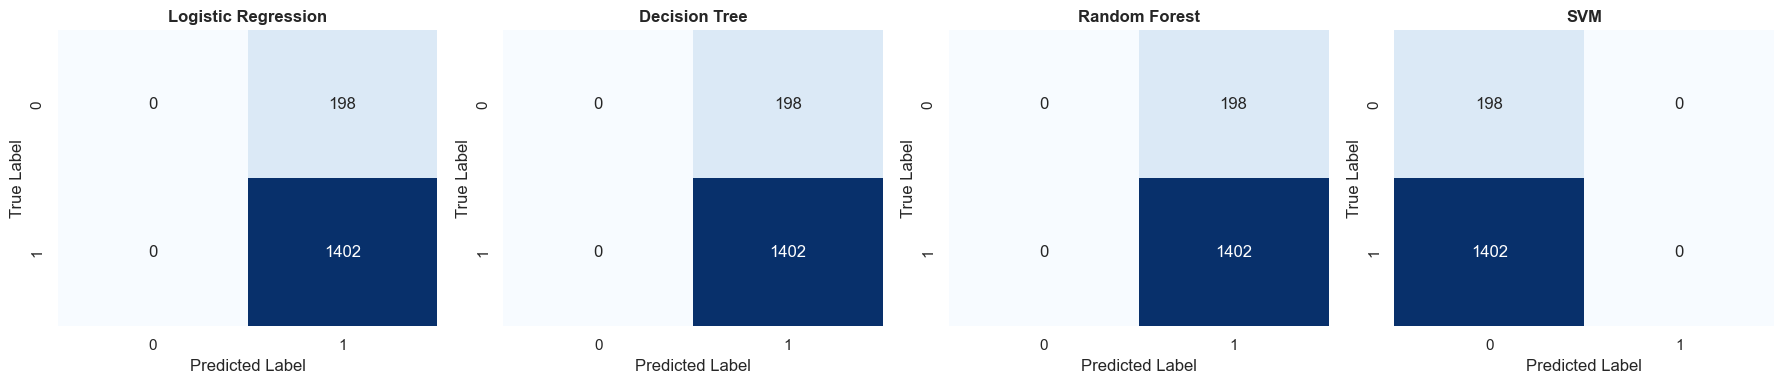

In [99]:
 
from sklearn.metrics import confusion_matrix


fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        ax=axes[idx], 
        cbar=False,
        xticklabels=['0', '1'],
        yticklabels=['0', '1']
    )
    
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\PC 118\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


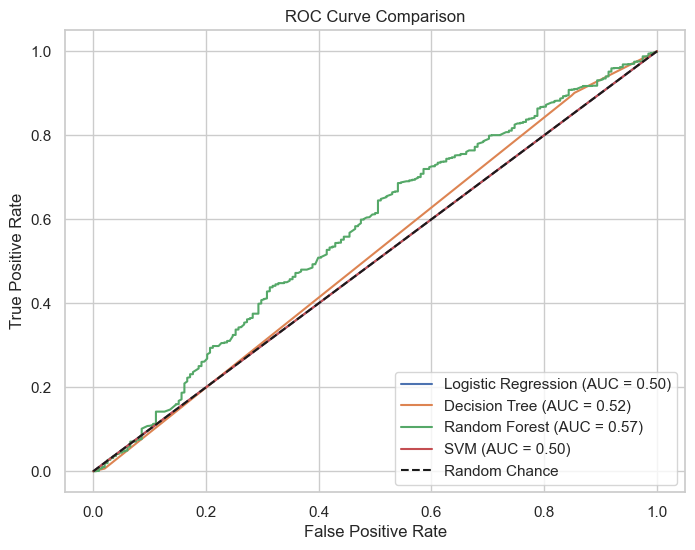

In [100]:
plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
        
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [101]:
import joblib

best_model_name = comparison_df.sort_values(
    by=['F1-Score', 'ROC-AUC'], ascending=False
).iloc[0]['Model']

best_model = trained_models[best_model_name]

print(f'Best Model Selected: {best_model_name}')

joblib.dump(best_model, 'best_model.pkl')

Best Model Selected: Random Forest


['best_model.pkl']